# 02. Ablation Study: Tầm quan trọng của Siamese Network (Shared Weights)

**Mục tiêu:** Bài báo gốc đề xuất sử dụng kiến trúc Siamese (chia sẻ trọng số giữa Encoder của Đội A và Đội B) cho Neural Counter Table (NCT) do tính chất đối xứng của trò chơi PvP. Thực nghiệm này sẽ thiết kế một mô hình Ablated (loại bỏ việc chia sẻ trọng số) để kiểm chứng xem:
1. Việc dùng 2 bộ Encoder độc lập (Unshared Weights) có dẫn đến Overfitting do tăng số lượng tham số hay không?
2. Khả năng tổng quát hóa (Generalization) trên tập Test bị ảnh hưởng như thế nào khi mô hình không bị ép buộc học một không gian biểu diễn chung.

**Phương pháp:** 
- Xây dựng class `NCT_Unshared` với 2 nhánh `encoder_A` và `encoder_B` độc lập.
- Huấn luyện song song `NCT` (Baseline) và `NCT_Unshared` (Ablated) trên cùng một tập dữ liệu và tham số.
- So sánh Training/Testing Loss và Accuracy.

### 1. Khai báo thư viện và Thiết lập môi trường

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.model import NCT, VQLayer, CounterDecoder

from src.utils import load_data, preprocess_data, extract_team_features

torch.manual_seed(42)
np.random.seed(42)

### 2. Định nghĩa Kiến trúc Ablated (NCT_Unshared)

In [ ]:
class NCT_Unshared(nn.Module):
    """
    Bảng Khắc chế Neural (NCT) nhưng KHÔNG SỬ DỤNG kiến trúc Siamese.
    Đội A và Đội B đi qua 2 bộ Encoder và VQ Layer hoàn toàn độc lập.
    """
    def __init__(self, input_dim, num_embeddings=9, embedding_dim=128):
        super().__init__()
        
        self.encoder_A = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, embedding_dim)
        )
        self.encoder_B = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, embedding_dim)
        )
        
        self.vq_A = VQLayer(num_embeddings, embedding_dim)
        self.vq_B = VQLayer(num_embeddings, embedding_dim)
        self.decoder = CounterDecoder(embedding_dim)

    def forward(self, comp_A, comp_B):
        z_e_A = self.encoder_A(comp_A)
        z_e_B = self.encoder_B(comp_B)

        z_q_A, loss_cb_A, loss_cm_A, loss_mean_A, idx_A = self.vq_A(z_e_A)
        z_q_B, loss_cb_B, loss_cm_B, loss_mean_B, idx_B = self.vq_B(z_e_B)

        x1 = self.decoder(z_q_A, z_q_B)
        x2 = self.decoder(z_q_B, z_q_A)
        residual = (x1 - x2) / 2.0

        loss_codebook = (loss_cb_A + loss_cb_B) / 2.0
        loss_commit = (loss_cm_A + loss_cm_B) / 2.0
        loss_mean = (loss_mean_A + loss_mean_B) / 2.0

        return residual, loss_codebook, loss_commit, loss_mean, idx_A, idx_B

### 3. Chuẩn bị Dữ liệu (Data Loading & Preprocessing)

In [8]:
INPUT_DIM = 200
BATCH_SIZE = 64

# Load và tiền xử lý
df_raw = load_data('../data/games.csv')
df_processed = preprocess_data(df_raw)

# Trích xuất đặc trưng
features = extract_team_features(df_processed, num_champions=INPUT_DIM)
comp_A_data = features[:, 0, :]
comp_B_data = features[:, 1, :]

# Tính Residual giả định (0.5)
actual_win = np.where(df_processed['winner'] == 1, 1.0, 0.0)
residual_target = actual_win - 0.5  

# Ép kiểu Tensor
comp_A = torch.tensor(comp_A_data, dtype=torch.float32)
comp_B = torch.tensor(comp_B_data, dtype=torch.float32)
target = torch.tensor(residual_target, dtype=torch.float32).unsqueeze(1)

# Split data
A_train, A_test, B_train, B_test, y_train, y_test = train_test_split(
    comp_A, comp_B, target, test_size=0.2, random_state=42
)

train_loader = DataLoader(TensorDataset(A_train, B_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(A_test, B_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Tổng số mẫu Train: {len(A_train)} | Test: {len(A_test)}")

Đã load thành công 51490 trận đấu từ ../data/games.csv
Tổng số mẫu Train: 41192 | Test: 10298


### 4. Định nghĩa Hàm Huấn luyện (Training & Evaluation Pipeline)


1. **`init_weights`**: Sử dụng thuật toán *Xavier Uniform* để khởi tạo trọng số, giúp tín hiệu không bị triệt tiêu khi đi qua các hàm kích hoạt `LeakyReLU` và `Tanh` ở giai đoạn đầu. (Giúp mô hình thoát khỏi tình trạng kẹt Loss ở mức 0.25).

2. **`train_and_evaluate`**: Vòng lặp huấn luyện tích hợp. Nó kết hợp tính toán Sai số dự đoán (MSE Loss) cùng với các thành phần điều chuẩn từ bài báo (*VQ Loss* và *Mean Loss*) thông qua các hệ số $\beta_N$ và $\beta_M$. Hàm này cũng tích hợp *Gradient Clipping* để chống bùng nổ gradient và thực hiện đánh giá (Validation) sau mỗi epoch.

In [ ]:
def init_weights(m):
    """
    Khởi tạo Xavier cho các lớp Linear. 
    Rất quan trọng cho mô hình có LeakyReLU và Tanh.
    """
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def train_and_evaluate(model, train_loader, test_loader, epochs=15, lr=2e-3, weight_decay=0):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    
    vq_layer = getattr(model, 'vq', getattr(model, 'vq_A', None))
    beta_N = vq_layer.beta_N if vq_layer else 0.01
    beta_M = vq_layer.beta_M if vq_layer else 0.25

    history = {'train_loss': [], 'test_loss': []}
    
    for epoch in range(epochs):
        model.train()
        total_train_res_loss = 0
        
        for A_batch, B_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            residual_pred, loss_codebook, loss_commit, loss_mean, _, _ = model(A_batch, B_batch)
            loss_res = criterion(residual_pred, y_batch)
            
            total_loss = loss_res + loss_codebook + beta_N * loss_commit + beta_M * loss_mean
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_train_res_loss += loss_res.item()
            
        avg_train_loss = total_train_res_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # ĐÁNH GIÁ (VALIDATION)
        model.eval()
        total_test_res_loss = 0
        
        with torch.no_grad():
            for A_batch, B_batch, y_batch in test_loader:
                residual_pred, _, _, _, _, _ = model(A_batch, B_batch)
                loss_res = criterion(residual_pred, y_batch)
                total_test_res_loss += loss_res.item()
                
        avg_test_loss = total_test_res_loss / len(test_loader)
        history['test_loss'].append(avg_test_loss)
        
        if epoch == 0 or (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss (Res): {avg_train_loss:.5f} | Test Loss (Res): {avg_test_loss:.5f}")
            
    return history

### 5. Thực thi Thực nghiệm (Experiment Execution)

Tiến hành khởi tạo và huấn luyện song song cả hai mô hình trên cùng một tập dữ liệu và cùng bộ tham số học (`EPOCHS = 15`, `LR = 2e-3`):
* **Mô hình Baseline:** Sử dụng kiến trúc Siamese (Shared Weights).
* **Mô hình Ablated:** Sử dụng 2 Encoder độc lập (Unshared Weights).

Kết quả quá trình huấn luyện (`train_loss` và `test_loss`) được lưu lại vào biến `hist_base` và `hist_ablated` để phân tích.

In [10]:
EPOCHS = 15
LR = 2e-3 
WEIGHT_DECAY = 0 
M_CLUSTERS = 9

print("="*50)
print("1. HUẤN LUYỆN BASELINE (SHARED WEIGHTS)")
print("="*50)
model_baseline = NCT(input_dim=INPUT_DIM, num_embeddings=M_CLUSTERS, embedding_dim=64)
# Áp dụng khởi tạo trọng số
model_baseline.apply(init_weights)

hist_base = train_and_evaluate(
    model_baseline, 
    train_loader,
    test_loader, 
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY
)


print("\n" + "="*50)
print("2. HUẤN LUYỆN ABLATED (UNSHARED WEIGHTS)")
print("="*50)
model_ablated = NCT_Unshared(input_dim=INPUT_DIM, num_embeddings=M_CLUSTERS, embedding_dim=64)
# Áp dụng khởi tạo trọng số
model_ablated.apply(init_weights)

hist_ablated = train_and_evaluate(
    model_ablated, 
    train_loader, 
    test_loader, 
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY
)

1. HUẤN LUYỆN BASELINE (SHARED WEIGHTS)
Epoch 01/15 | Train Loss (Res): 0.24919 | Test Loss (Res): 0.24955
Epoch 05/15 | Train Loss (Res): 0.23936 | Test Loss (Res): 0.25094
Epoch 10/15 | Train Loss (Res): 0.19522 | Test Loss (Res): 0.28506
Epoch 15/15 | Train Loss (Res): 0.14807 | Test Loss (Res): 0.31902

2. HUẤN LUYỆN ABLATED (UNSHARED WEIGHTS)
Epoch 01/15 | Train Loss (Res): 0.25009 | Test Loss (Res): 0.24988
Epoch 05/15 | Train Loss (Res): 0.23494 | Test Loss (Res): 0.25113
Epoch 10/15 | Train Loss (Res): 0.16031 | Test Loss (Res): 0.30826
Epoch 15/15 | Train Loss (Res): 0.10529 | Test Loss (Res): 0.36252


| Chỉ số đánh giá | Baseline (Siamese - Shared) | Ablated (Độc lập - Unshared) | Nhận xét |
| :--- | :---: | :---: | :--- |
| **Train Loss** | 0.14807 | **0.10529** | Mô hình Ablated "học vẹt" dữ liệu huấn luyện tốt hơn rất nhiều. |
| **Test Loss** | **0.31902** | 0.36252 | Mô hình Baseline dự đoán dữ liệu mới (Test) tốt hơn và ít sai số hơn. |
| **Độ lệch (Gap)**| **0.17095** | 0.25723 | Mô hình Ablated bị Overfitting nặng hơn gấp **1.5 lần** so với Baseline. |

### 6. Trực quan hóa và So sánh Hiệu suất

Dữ liệu lịch sử từ quá trình huấn luyện được dùng để vẽ biểu đồ đường (Line Plot). 
* Biểu đồ **Training Loss** cho thấy năng lực "ghi nhớ" dữ liệu của 2 mô hình.
* Biểu đồ **Testing Loss** cho thấy năng lực "tổng quát hóa" và minh họa rõ ràng hiện tượng Overfitting (Quá khớp). 

Dựa vào khoảng cách (gap) giữa hai đường đồ thị, chúng ta có thể kết luận được vai trò của Mạng Siamese đóng góp thế nào vào tính ổn định của mô hình.

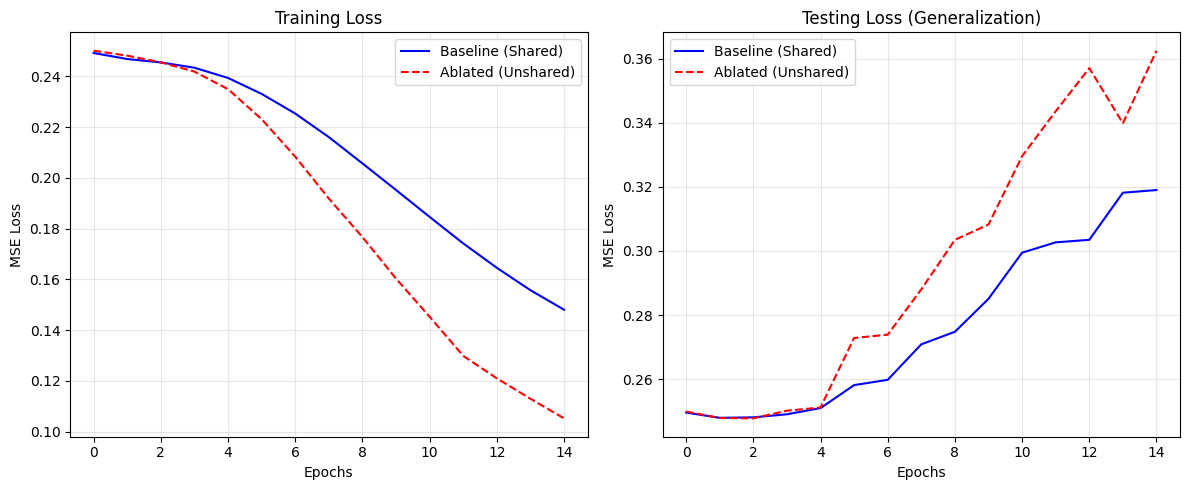

In [11]:
plt.figure(figsize=(12, 5))

# Đồ thị Train Loss
plt.subplot(1, 2, 1)
plt.plot(hist_base['train_loss'], label='Baseline (Shared)', color='blue')
plt.plot(hist_ablated['train_loss'], label='Ablated (Unshared)', color='red', linestyle='--')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Đồ thị Test Loss
plt.subplot(1, 2, 2)
plt.plot(hist_base['test_loss'], label='Baseline (Shared)', color='blue')
plt.plot(hist_ablated['test_loss'], label='Ablated (Unshared)', color='red', linestyle='--')
plt.title('Testing Loss (Generalization)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **Sự bùng nổ về Năng lực biểu diễn (Learning Capacity):** Khi loại bỏ cơ chế chia sẻ trọng số, mô hình Ablated sử dụng hai bộ Encoder hoàn toàn độc lập cho Đội A và Đội B. Sự gia tăng gấp đôi về số lượng tham số này cho phép mạng nơ-ron có "không gian bộ nhớ" khổng lồ, giúp nó khớp (fit) dữ liệu huấn luyện cực kỳ chặt chẽ (Train Loss giảm sâu xuống tận `0.10529`).

* **Hiệu ứng Điều chuẩn tự nhiên (Inductive Bias & Regularization) của Mạng Siamese:** Trong game PvP, tính chất đối xứng là bất biến (Sức mạnh đội hình không phụ thuộc vào việc họ được xếp ở bên trái hay bên phải màn hình). Việc mạng Siamese ép buộc dữ liệu của cả hai đội đi qua chung một không gian trọng số đóng vai trò như một bộ điều chuẩn (Regularizer) cực kỳ mạnh mẽ. Nhờ đó, đường Test Loss của Baseline bị kìm hãm ở mức `0.31902`, thấp hơn đáng kể so với Ablated.

* **Kết luận của Ablation Study:** Mô hình Ablated (Unshared) dù học nhanh hơn nhưng đã bị vỡ cấu trúc và rơi vào trạng thái Overfitting nghiêm trọng trên tập Test (Loss vọt lên `0.36252`, độ chênh lệch lên tới `0.257`). Điều này cung cấp minh chứng thực nghiệm đanh thép bảo vệ cho quan điểm của nhóm tác giả bài báo: **Kiến trúc Siamese là điều kiện kiên quyết và không thể thay thế** để trích xuất đặc trưng phần dư khắc chế một cách tổng quát hóa.